# Minist Classification

Load Packages

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

Load dataset

In [2]:
(xtrain, ytrain), (xtest, ytest) = keras.datasets.mnist.load_data()
print(xtrain.shape, ytrain.shape)
print(xtest.shape, ytest.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


Visualize dataset

In [3]:

def get_classes_indices(
    x,
    y,
    samples_per_class: int = 5,
    seed: int = 42,
):
    """
    Select sample indices per class.

    Returns
    -------
    selected_indices : np.ndarray
        Flattened array of selected indices
    num_classes : int
        Number of unique classes
    """
    rng = np.random.default_rng(seed)

    y = np.asarray(y)
    unique_classes = np.unique(y)
    num_classes = len(unique_classes)

    selected_indices = []

    for label in unique_classes:
        class_indices = np.where(y == label)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Class {label} has only {len(class_indices)} samples, "
                f"but {samples_per_class} were requested."
            )

        chosen = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )
        selected_indices.extend(chosen)

    return np.array(selected_indices), num_classes


In [4]:

def visualize_data(
    x,
    y,
    samples_per_class: int = 4,
    seed: int = 42,
    class_names=None,
    cmap: str = "gray"
):
    """
    Visualize sample images per class.

    Parameters
    ----------
    x : array-like
        Image data of shape (N, H, W[, C])
    y : array-like
        Labels of shape (N,)
    samples_per_class : int
        Number of samples to show per class
    seed : int
        Random seed for reproducibility
    class_names : list[str], optional
        Names for each class index
    cmap : str
        Colormap for grayscale images
    """

    selected_indices, num_classes = get_classes_indices(
        x=x,
        y=y,
        samples_per_class=samples_per_class,
        seed=seed
    )

    plt.figure(
    figsize=(num_classes * 2.0, samples_per_class * 2.5))

    for plot_idx, image_idx in enumerate(selected_indices):
        plt.subplot(num_classes, samples_per_class, plot_idx + 1)

        image = x[image_idx]
        label = y[image_idx]

        if image.ndim == 2:  # grayscale
            plt.imshow(image, cmap=cmap)
        else:
            plt.imshow(image)

        if class_names:
            plt.title(class_names[label], fontsize=9)
        else:
            plt.title(f"Class {label}", fontsize=9)
        plt.subplots_adjust(bottom=0.1, right=0.2, top=0.2, left=0.1)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


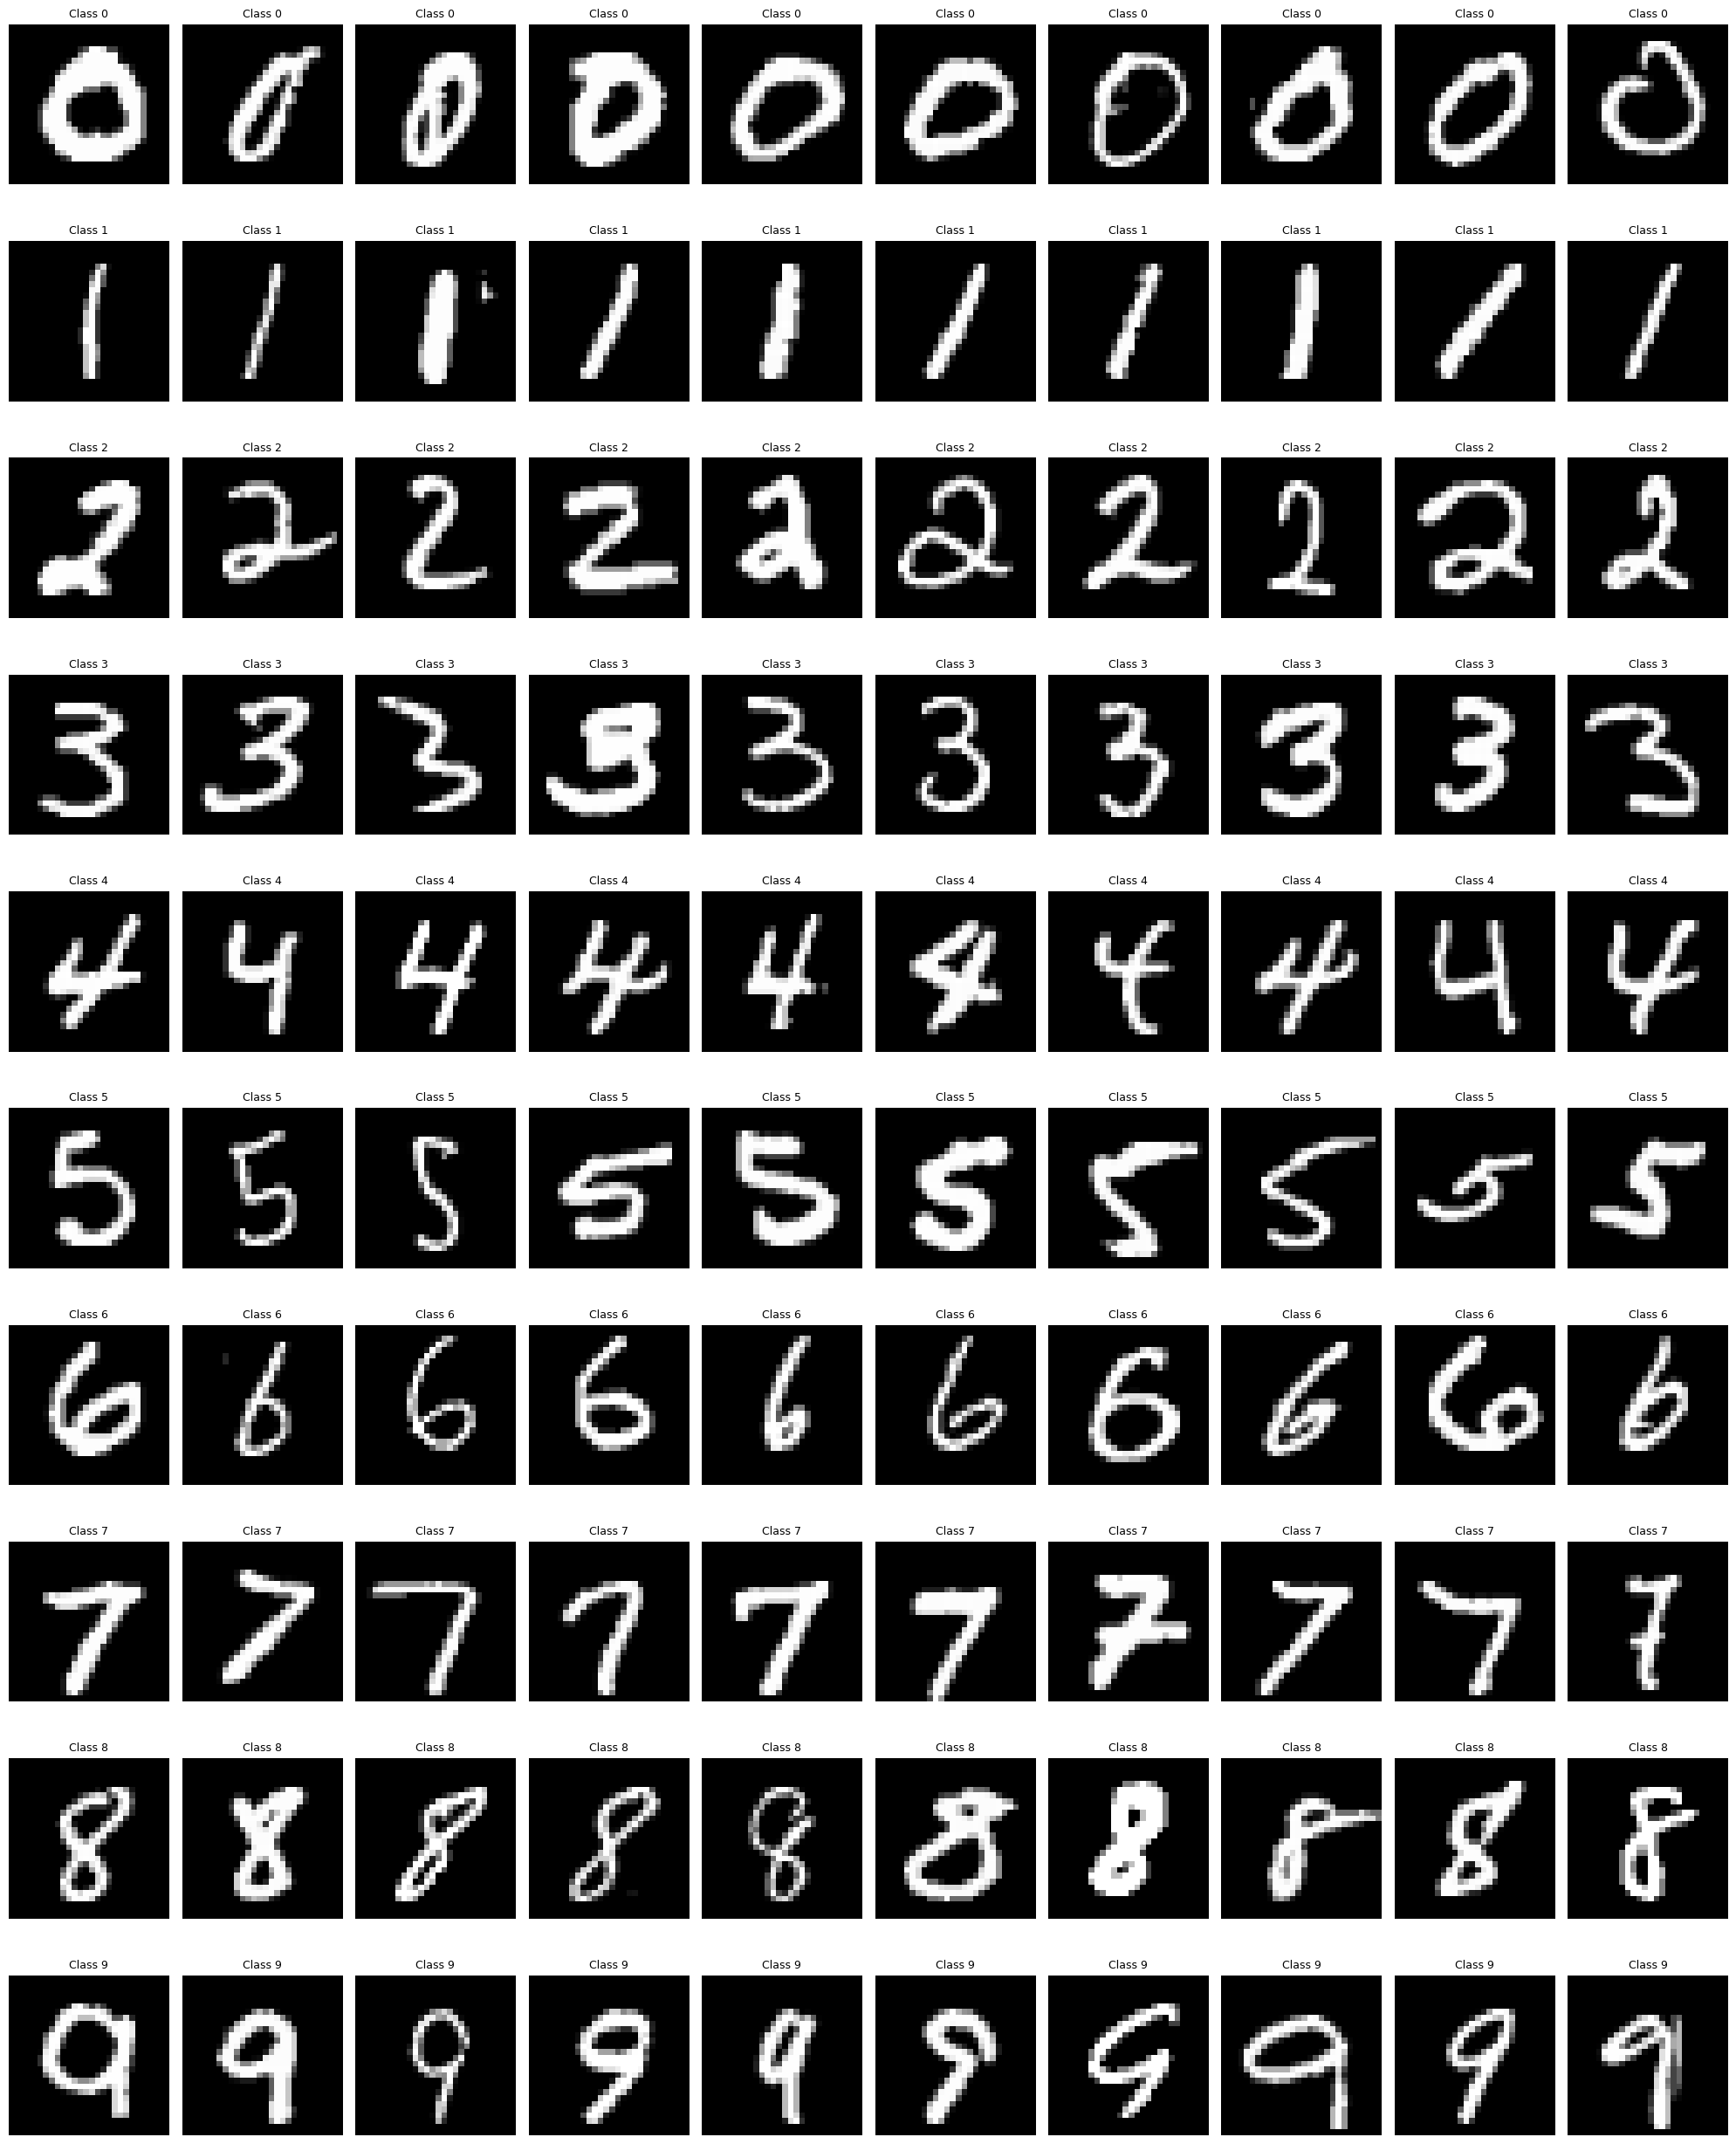

In [5]:
visualize_data(xtrain, ytrain, 10)

Preprocess data

In [6]:
# check data range and types
max_pixel_value = xtrain.max()
min_pixel_value = xtrain.min()
print(f"Minimum digit value: {min_pixel_value}")
print(f"Maximum digit value: {max_pixel_value}")
print(f"image dtype: {xtrain.dtype}")
print(f"target dtype: {ytrain.dtype}")

Minimum digit value: 0
Maximum digit value: 255
image dtype: uint8
target dtype: uint8


In [ ]:
# normalize and cast
normalized_xtrain = xtrain.astype("float32") / max_pixel_value
normalized_xtest = xtest.astype("float32") / max_pixel_value

print(normalized_xtrain.min(), normalized_xtrain.max())
print(normalized_xtrain.dtype, ytrain.dtype)

0.0 1.0
float32 uint8


Modeling

In [ ]:
#  Fully connected neural network
def get_model(input_shape, num_classes, activation="relu"):
    model = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            keras.layers.Flatten(),
            keras.layers.Dense(256, activation=activation),
            keras.layers.Dense(128, activation=activation),
            keras.layers.Dense(64, activation=activation),
            keras.layers.Dense(num_classes, activation="softmax")
        ]
    )

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer = "adam",
        metrics = ["accuracy"]
    )

    model.summary()

    return model


In [ ]:
# build and fit model
input_shape = xtrain.shape[1:]
num_classes = len(np.unique(ytrain))
model = get_model(input_shape=input_shape, num_classes=num_classes)

# training hyperparameters
EPOCHS = 10
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.1

model_history = model.fit(normalized_xtrain, ytrain, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALIDATION_SPLIT, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8571 - loss: 0.4760 - val_accuracy: 0.9663 - val_loss: 0.1108
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9676 - loss: 0.1037 - val_accuracy: 0.9753 - val_loss: 0.0765
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9802 - loss: 0.0627 - val_accuracy: 0.9778 - val_loss: 0.0760
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9863 - loss: 0.0429 - val_accuracy: 0.9762 - val_loss: 0.0802
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9906 - loss: 0.0300 - val_accuracy: 0.9797 - val_loss: 0.0765
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9913 - loss: 0.0266 - val_accuracy: 0.9790 - val_loss: 0.0785
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9916 - loss: 0.0245 - val_accuracy: 0.9787 - val_loss: 0.0873
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9930 - loss: 0.0211 - val_accuracy: 0.

Plot training curve

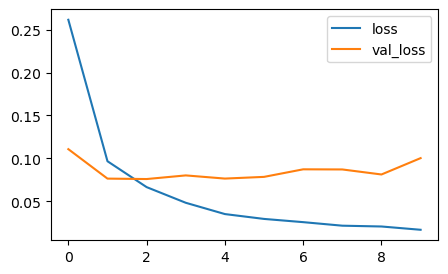

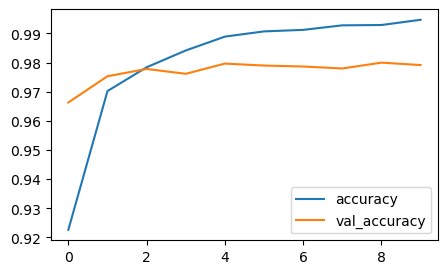

In [ ]:
# visualize metrics
def plot_metrics(history, metric="accuracy"):
    metrics = history.history.keys()
    plt.figure(figsize=(5, 3))
    plt.plot(history.history.get(metric), label=metric)
    title = f"Training {metric.capitalize()}"
    validation_metric = "val_" + metric
    if validation_metric in metrics:
        plt.plot(history.history.get(validation_metric), label=validation_metric)
        # title += f" Vs {validation_metric.capitalize()}"
    
    plt.legend()
    
plot_metrics(model_history, metric="loss")
plot_metrics(model_history, metric="accuracy")

Evaluate model

In [ ]:
# accuracy
loss, accuracy = model.evaluate(normalized_xtest, ytest)
print(f"Accuracy: {accuracy:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 23.7410
Accuracy: 97.88%


In [ ]:
# predictions
test_pred = model.predict(normalized_xtest)
test_pred = np.argmax(test_pred, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [13]:
# classification report
from sklearn.metrics import classification_report

labels=list(range(num_classes))
target_names = [f"class {idx}" for idx in range(num_classes)]
report = classification_report(ytest, test_pred, labels=labels, target_names=target_names)
print(report)

              precision    recall  f1-score   support

     class 0       0.99      0.99      0.99       980
     class 1       0.99      0.99      0.99      1135
     class 2       0.98      0.97      0.98      1032
     class 3       0.98      0.98      0.98      1010
     class 4       0.98      0.98      0.98       982
     class 5       0.98      0.98      0.98       892
     class 6       0.98      0.98      0.98       958
     class 7       0.99      0.95      0.97      1028
     class 8       0.95      0.98      0.97       974
     class 9       0.95      0.98      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



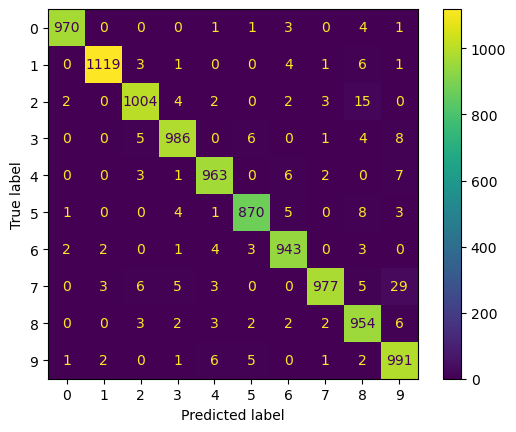

In [14]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(ytest, test_pred)
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show()

Error analysis

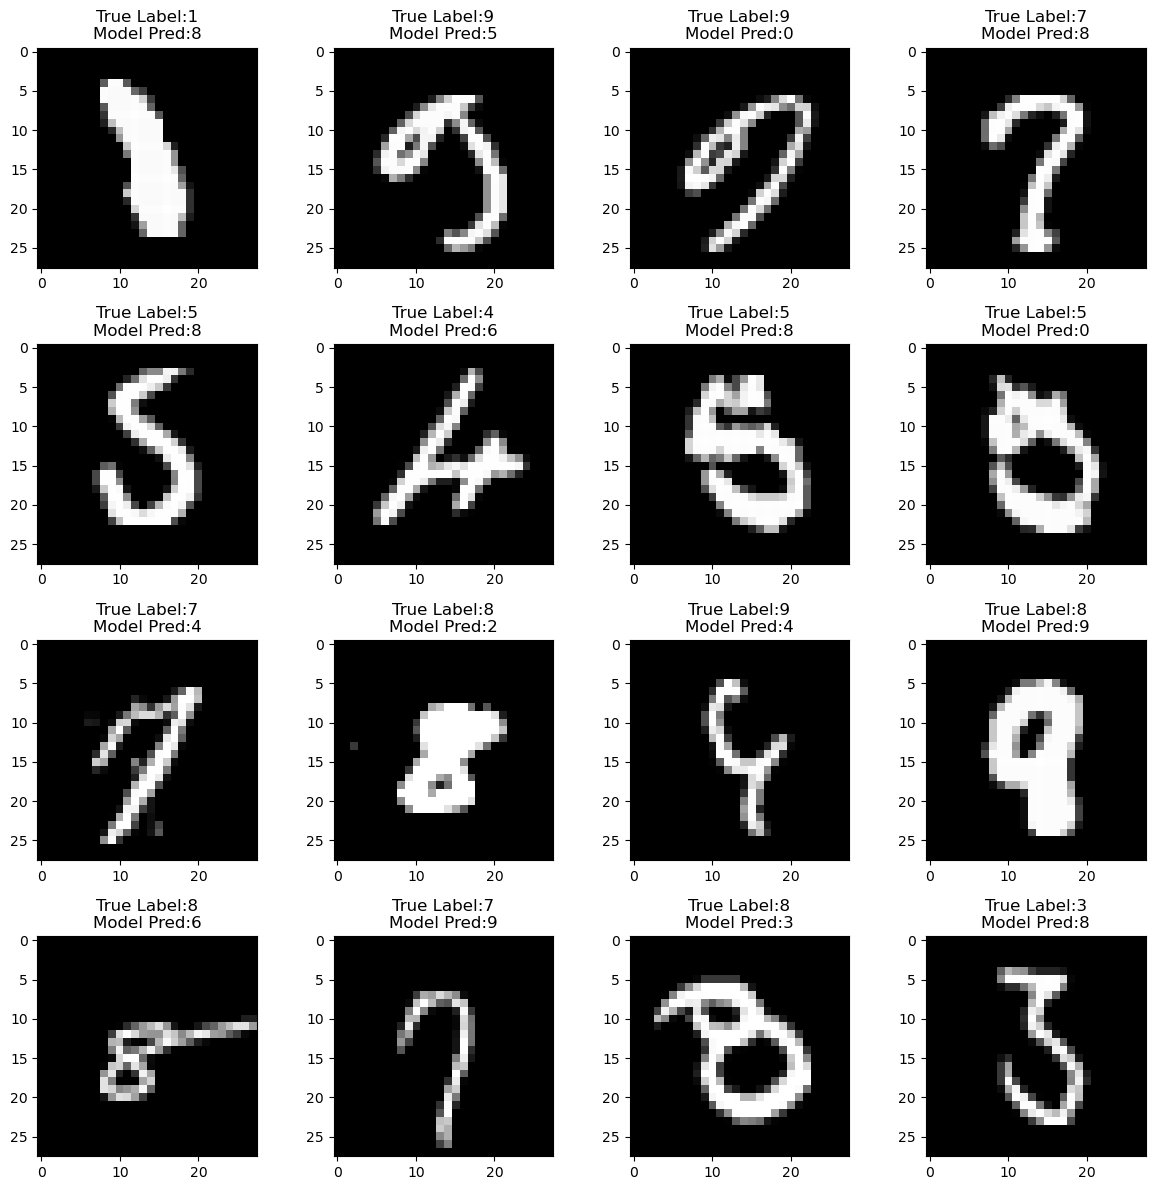

In [15]:
def visualize_wrong_predictions(x, ytrue, ypred, n_samples=10, seed=42):
    wrong_predictions = ytrue != ypred
    X_mispredicted = x[wrong_predictions]
    actual_pred = ytrue[wrong_predictions]
    wrong_pred = ypred[wrong_predictions]

    np.random.seed(seed)
    indices = np.random.permutation(len(X_mispredicted))[:n_samples]

    n_wrong = len(wrong_pred)
    if n_samples > n_wrong:
        raise ValueError(f"You can only visualize upto {n_wrong} samples.")

    nrows = int(np.ceil(np.sqrt(n_samples)))
    ncols = int(np.floor(np.sqrt(n_samples)))

    plt.figure(figsize=(nrows*3, ncols*3))
    for subplot_idx, image_idx in enumerate(indices):
        plt.subplot(nrows, ncols, subplot_idx+1)
        plt.imshow(X_mispredicted[image_idx], cmap="gray")
        title = f"True Label:{actual_pred[image_idx]}\nModel Pred:{wrong_pred[image_idx]}"
        plt.title(title)
    
    plt.tight_layout()

    plt.show()

visualize_wrong_predictions(normalized_xtest, ytest, test_pred, n_samples=16)

Convolution Neural Network

In [ ]:
def get_cnn_model(input_shape, num_classes, activation="relu"):
    
    model = keras.Sequential([
        
        keras.Input(shape=input_shape), # added for visualization
        
        keras.layers.Reshape(input_shape + (1,)),
        
        keras.layers.Conv2D(filters=128, kernel_size=3, padding="same"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.ReLU(),

        keras.layers.Conv2D(filters=64, kernel_size=3, padding="same"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.ReLU(),

        keras.layers.Flatten(),

        keras.layers.Dense(units=num_classes, activation="softmax")
    ])

    model.summary()

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )

    return model

In [17]:
xtrain.shape

(60000, 28, 28)

In [18]:
input_shape = xtrain.shape[1:]

cnn_model = get_cnn_model(input_shape=input_shape, num_classes=num_classes)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,442 (415.79 KB)

 Trainable params: 106,442 (415.79 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cnn_history = cnn_model.fit(normalized_xtrain, ytrain,
              epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=VALIDATION_SPLIT)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 51ms/step - accuracy: 0.8812 - loss: 0.3917 - val_accuracy: 0.9805 - val_loss: 0.0678
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9831 - loss: 0.0561 - val_accuracy: 0.9852 - val_loss: 0.0508
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9908 - val_loss: 0.0360
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9915 - val_loss: 0.0302
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9908 - val_loss: 0.0317
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.9947 - loss: 0.0164 - val_accuracy: 0.9915 - val_loss: 0.0356
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 44ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9932 - val_loss: 0.0318
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9964 - loss: 0.0106 - 

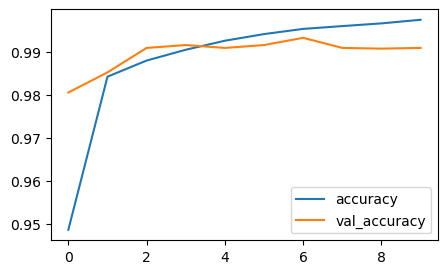

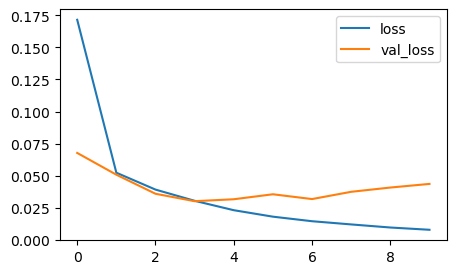

In [20]:
plot_metrics(cnn_history, metric="accuracy")
plot_metrics(cnn_history, metric="loss")

In [26]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(normalized_xtest, ytest)
print(f"accuracy: {cnn_accuracy:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9893 - loss: 0.0442
accuracy: 99.08%


In [22]:
cnn_pred = cnn_model.predict(normalized_xtest)
cnn_pred = np.argmax(cnn_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [23]:
report = classification_report(ytest, cnn_pred, labels=labels, target_names=target_names)
print(report)

              precision    recall  f1-score   support

     class 0       0.99      0.99      0.99       980
     class 1       0.99      1.00      0.99      1135
     class 2       0.99      0.99      0.99      1032
     class 3       0.99      1.00      0.99      1010
     class 4       0.99      0.99      0.99       982
     class 5       0.99      0.98      0.99       892
     class 6       1.00      0.98      0.99       958
     class 7       1.00      0.99      0.99      1028
     class 8       0.98      0.99      0.99       974
     class 9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



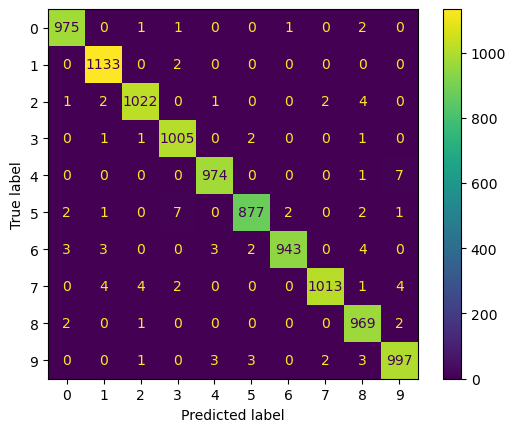

In [24]:
cm = confusion_matrix(ytest, cnn_pred)
display = ConfusionMatrixDisplay(cm)
display.plot()
plt.show()

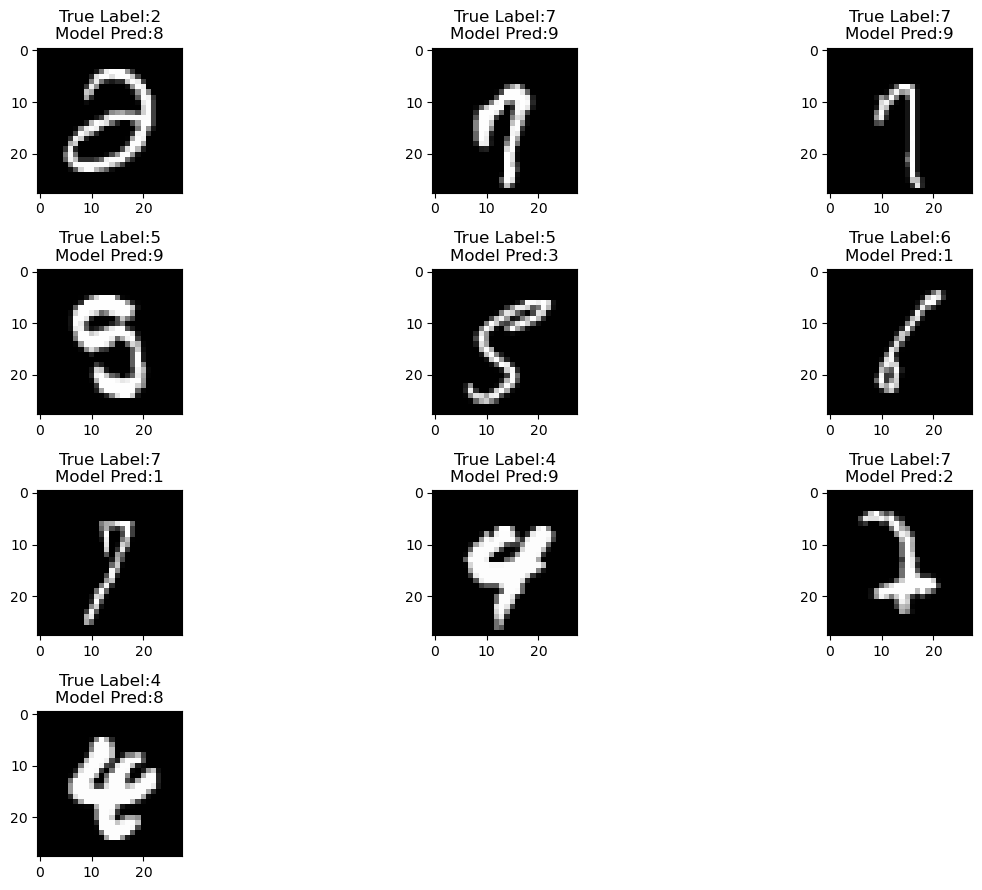

In [25]:
visualize_wrong_predictions(normalized_xtest, ytest, cnn_pred)

Conclusions

- Fully Connected Network Model
    1. The FCN model achieved an accuracy of 97.88% on the test set.
    2. Each training epoch of the FCN model takes 4 seconds on average.
    3. The FCN model takes only a second to make inference on 10,000 test images.
    4. The architecture has roughly 243 thousand parameters.

- CNN Model
    1. The CNN model achieved an accuracy of 99.08% on the test set.
    2. Each training epoch of the CNN model takes about 42 seconds.
    3. The CNN model takes only 3 seconds to make inference on 10,000 test images.
    4. The architecture has roughly 107 thousand parameters.


- The choice of model for production depends on several metrics, which may include:
    - Accuracy: The CNN model has higher accuracy than the FCN model.
    - Training time: The FCN model is faster to train than the CNN model. This is important for scheduled retraining.
    - Inference time: The FCN model achieves lower inference time than the CNN.